Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows of the dataset:
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Dataset Description:
               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   

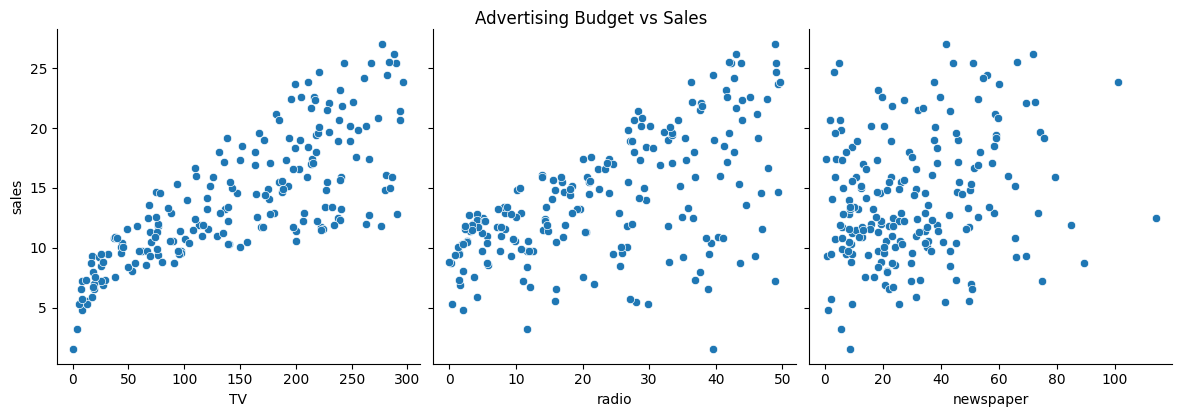

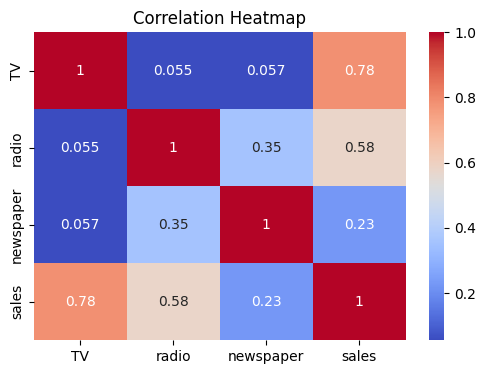


Model Coefficients: [0.04472952 0.18919505 0.00276111]
Model Intercept: 2.979067338122629
Mean Squared Error: 3.174
R² Score: 0.899

Actual vs Predicted Sales:
     Actual  Predicted
95     16.9  16.408024
15     22.4  20.889882
30     21.4  21.553843
158     7.3  10.608503
128    24.7  22.112373


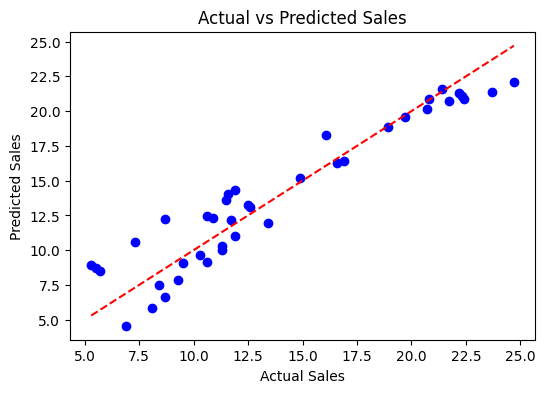

In [10]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Replace with your actual path to the CSV
# IMPORTANT: Please verify this path. Ensure the file 'Advertising.csv' exists at this exact location in your Google Drive.
file_path = '/content/drive/MyDrive/ML_Project/Advertising.csv'

# Step 2: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 3: Load Dataset
data = pd.read_csv(file_path)

# Check the first few rows
print("First 5 rows of the dataset:")
print(data.head())

# Drop unnecessary index column if exists
if 'Unnamed: 0' in data.columns:
    data = data.drop('Unnamed: 0', axis=1)

# Step 4: Data Exploration
print("\nDataset Info:")
print(data.info())

print("\nDataset Description:")
print(data.describe())

# Step 5: Visualize relationships
sns.pairplot(data, x_vars=['TV', 'radio', 'newspaper'], y_vars='sales', height=4, aspect=1, kind='scatter')
plt.suptitle("Advertising Budget vs Sales", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Step 6: Prepare Data for Linear Regression
X = data[['TV', 'radio', 'newspaper']]  # Features
y = data['sales']                        # Target

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Make Predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

# Step 10: Compare Predictions vs Actual
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nActual vs Predicted Sales:")
print(comparison.head())

# Optional: Plot Actual vs Predicted
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [11]:
# Use only strong features
X = data[['TV', 'radio']]
y = data['sales']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 3.137948009068354
R²: 0.9005833101920356


In [12]:
splits = [0.1, 0.2, 0.3, 0.4]

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        data[['TV', 'radio']], data['sales'],
        test_size=test_size, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nTest Size: {test_size}")
    print("R²:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))


Test Size: 0.1
R²: 0.9059608902736263
MSE: 3.0891353839787694

Test Size: 0.2
R²: 0.9005833101920356
MSE: 3.137948009068354

Test Size: 0.3
R²: 0.8656253548947074
MSE: 3.669047054530681

Test Size: 0.4
R²: 0.8698031390858897
MSE: 3.290956555599666


In [13]:
# --- 5-Fold Cross-Validation ---
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# Set up 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate R² for each fold
r2_scores = cross_val_score(model, data[['TV', 'radio']], data['sales'], cv=kf, scoring='r2')
print("R² scores for each fold:", r2_scores)
print("Average R²:", np.mean(r2_scores))

# Evaluate MSE for each fold
mse_scorer = make_scorer(mean_squared_error)
mse_scores = cross_val_score(model, data[['TV', 'radio']], data['sales'], cv=kf, scoring=mse_scorer)
print("MSE for each fold:", mse_scores)
print("Average MSE:", np.mean(mse_scores))

R² scores for each fold: [0.90058331 0.81983792 0.93492767 0.90130517 0.8651222 ]
Average R²: 0.8843552533958674
MSE for each fold: [3.13794801 3.2776887  1.59963883 2.82158599 3.7689908 ]
Average MSE: 2.9211704660200666


In [14]:
# --- Polynomial Regression with 5-Fold CV ---

from sklearn.preprocessing import PolynomialFeatures

# Transform features to include polynomial terms (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(data[['TV', 'radio']])

# Reuse your linear regression model
model_poly = LinearRegression()

# 5-Fold CV setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate R² for polynomial regression
r2_scores_poly = cross_val_score(model_poly, X_poly, data['sales'], cv=kf, scoring='r2')
print("Polynomial Regression R² scores for each fold:", r2_scores_poly)
print("Average R²:", np.mean(r2_scores_poly))

# Evaluate MSE for polynomial regression
mse_scorer = make_scorer(mean_squared_error)
mse_scores_poly = cross_val_score(model_poly, X_poly, data['sales'], cv=kf, scoring=mse_scorer)
print("Polynomial Regression MSE for each fold:", mse_scores_poly)
print("Average MSE:", np.mean(mse_scores_poly))

Polynomial Regression R² scores for each fold: [0.98846279 0.98491403 0.99332319 0.98746673 0.96856454]
Average R²: 0.9845462565607818
Polynomial Regression MSE for each fold: [0.36415587 0.27445904 0.16413254 0.35831344 0.87842442]
Average MSE: 0.407897064013385


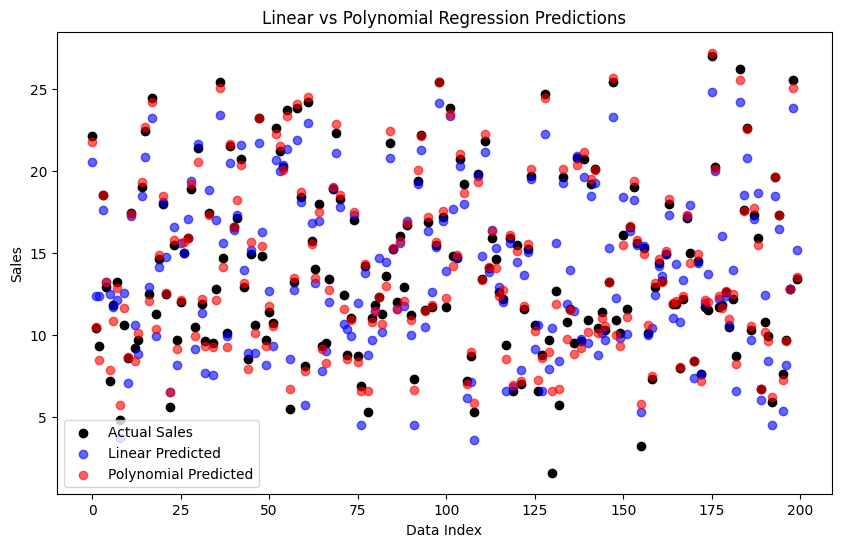

In [15]:
# Fit Linear Regression on full dataset
model.fit(data[['TV', 'radio']], data['sales'])
y_pred_linear = model.predict(data[['TV', 'radio']])

# Fit Polynomial Regression on full dataset
model_poly.fit(X_poly, data['sales'])
y_pred_poly = model_poly.predict(X_poly)

# Plot actual vs predicted
plt.figure(figsize=(10,6))
plt.scatter(range(len(data['sales'])), data['sales'], color='black', label='Actual Sales')
plt.scatter(range(len(data['sales'])), y_pred_linear, color='blue', alpha=0.6, label='Linear Predicted')
plt.scatter(range(len(data['sales'])), y_pred_poly, color='red', alpha=0.6, label='Polynomial Predicted')
plt.title('Linear vs Polynomial Regression Predictions')
plt.xlabel('Data Index')
plt.ylabel('Sales')
plt.legend()
plt.show()

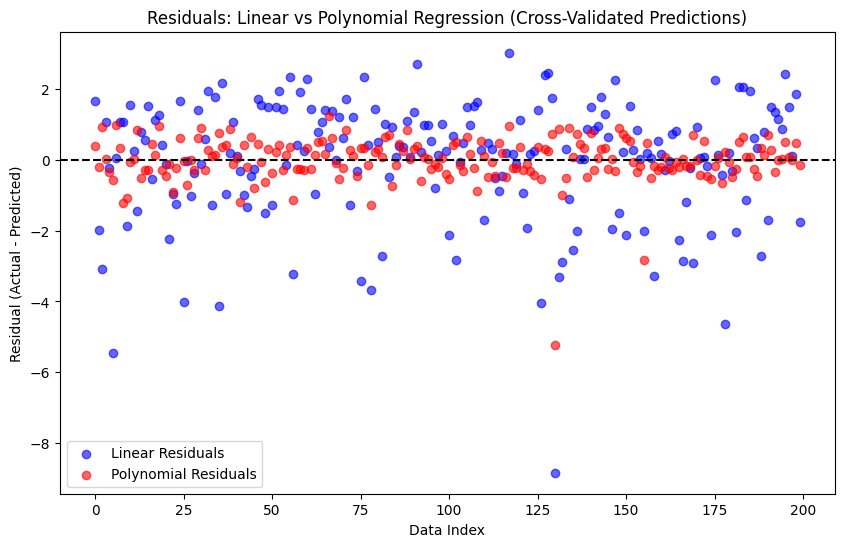

In [16]:
from sklearn.model_selection import cross_val_predict

# Get cross-validated predictions
y_pred_linear_cv = cross_val_predict(model, data[['TV', 'radio']], data['sales'], cv=kf)
y_pred_poly_cv   = cross_val_predict(model_poly, X_poly, data['sales'], cv=kf)

# Calculate residuals
residuals_linear = data['sales'] - y_pred_linear_cv
residuals_poly   = data['sales'] - y_pred_poly_cv

# Plot residuals
plt.figure(figsize=(10,6))
plt.scatter(range(len(data['sales'])), residuals_linear, color='blue', alpha=0.6, label='Linear Residuals')
plt.scatter(range(len(data['sales'])), residuals_poly, color='red', alpha=0.6, label='Polynomial Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals: Linear vs Polynomial Regression (Cross-Validated Predictions)')
plt.xlabel('Data Index')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.show()

In [17]:
# --- Random Forest Regression with 5-Fold CV ---
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest (you can tweak n_estimators or max_depth)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 5-Fold CV setup (reuse kf if already defined)
# Evaluate R²
r2_scores_rf = cross_val_score(rf_model, data[['TV', 'radio']], data['sales'], cv=kf, scoring='r2')
print("Random Forest R² scores for each fold:", r2_scores_rf)
print("Average R²:", np.mean(r2_scores_rf))

# Evaluate MSE
mse_scores_rf = cross_val_score(rf_model, data[['TV', 'radio']], data['sales'], cv=kf, scoring=make_scorer(mean_squared_error))
print("Random Forest MSE for each fold:", mse_scores_rf)
print("Average MSE:", np.mean(mse_scores_rf))

Random Forest R² scores for each fold: [0.98590154 0.98474739 0.9863628  0.98599151 0.9723595 ]
Average R²: 0.9830725481029319
Random Forest MSE for each fold: [0.44499805 0.2774907  0.3352362  0.40048862 0.77237902]
Average MSE: 0.44611851999999946
